In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports successful")

✓ Imports successful


In [4]:
print("="*60)
print("LOADING MODELS AND DATA")
print("="*60)

# Load data
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

print(f"✓ Test set: {X_test.shape}")

# Load baseline model
baseline_model = joblib.load('../models/base_classifier/xgboost_baseline.pkl')
baseline_metrics = joblib.load('../models/base_classifier/baseline_metrics.pkl')
baseline_accuracy = baseline_metrics['test_metrics']['accuracy']

print(f"✓ Baseline accuracy: {baseline_accuracy:.4f}")

# Load surrogate model
class SurrogateNet(nn.Module):
    def __init__(self, input_dim):
        super(SurrogateNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 32)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(32, 2)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        x = self.fc4(x)
        return x

input_dim = X_test.shape[1]
surrogate_model = SurrogateNet(input_dim)
surrogate_model.load_state_dict(torch.load('../models/attacks/surrogate_model.pth'))
surrogate_model.eval()

print("✓ Surrogate model loaded")

# Load previous attack results
fgsm_results = joblib.load('../models/attacks/fgsm_results.pkl')
pgd_results = joblib.load('../models/attacks/pgd_results.pkl')

print(f"✓ FGSM best accuracy: {fgsm_results['best_accuracy']:.4f}")
print(f"✓ PGD best accuracy: {pgd_results['best_config']['accuracy']:.4f}")


LOADING MODELS AND DATA
✓ Test set: (207974, 41)
✓ Baseline accuracy: 0.9998
✓ Surrogate model loaded
✓ FGSM best accuracy: 0.6297
✓ PGD best accuracy: 0.6364


In [5]:
print("\n" + "="*60)
print("C&W (CARLINI & WAGNER) ATTACK")
print("="*60)

print("""
C&W is the most sophisticated adversarial attack:

FGSM/PGD Approach:
  - Fixed perturbation budget (epsilon)
  - Generate adversarial examples within that budget
  - Question: "Given epsilon, can I fool the model?"

C&W Approach:
  - Find MINIMUM perturbation that fools the model
  - Uses optimization to minimize perturbation
  - Question: "What's the smallest change that works?"

Optimization Problem:
  minimize: ||δ||² + c × L(x + δ, t)
  
  Where:
  - δ: perturbation (what we're optimizing)
  - ||δ||²: L2 norm of perturbation (keep it small)
  - c: constant balancing perturbation vs attack success
  - L(x + δ, t): loss function encouraging misclassification
  - t: target class (for targeted attacks) or just != true class

Why C&W is Stronger:
  1. Optimizes perturbation magnitude (not fixed epsilon)
  2. Uses Adam optimizer (better than gradient sign)
  3. Iterative refinement (100-1000 steps)
  4. Creates imperceptible adversarial examples
  5. Defeats many defenses that stop FGSM/PGD

Implementation:
  - We'll use a simplified C&W (L2 variant)
  - Untargeted attack (just fool the model, don't target specific class)
  - 100 iterations with Adam optimizer
""")


C&W (CARLINI & WAGNER) ATTACK

C&W is the most sophisticated adversarial attack:

FGSM/PGD Approach:
  - Fixed perturbation budget (epsilon)
  - Generate adversarial examples within that budget
  - Question: "Given epsilon, can I fool the model?"

C&W Approach:
  - Find MINIMUM perturbation that fools the model
  - Uses optimization to minimize perturbation
  - Question: "What's the smallest change that works?"

Optimization Problem:
  minimize: ||δ||² + c × L(x + δ, t)

  Where:
  - δ: perturbation (what we're optimizing)
  - ||δ||²: L2 norm of perturbation (keep it small)
  - c: constant balancing perturbation vs attack success
  - L(x + δ, t): loss function encouraging misclassification
  - t: target class (for targeted attacks) or just != true class

Why C&W is Stronger:
  1. Optimizes perturbation magnitude (not fixed epsilon)
  2. Uses Adam optimizer (better than gradient sign)
  3. Iterative refinement (100-1000 steps)
  4. Creates imperceptible adversarial examples
  5. Defeat

In [6]:
print("\n" + "="*60)
print("IMPLEMENTING C&W L2 ATTACK")
print("="*60)

def cw_l2_attack(model, x, y, c=1.0, kappa=0, learning_rate=0.01, max_iter=100):
    """
    C&W L2 attack implementation
    
    Args:
        model: Neural network model
        x: Input tensor (clean samples)
        y: True labels
        c: Constant balancing perturbation size vs attack success
        kappa: Confidence parameter (how confident should misclassification be)
        learning_rate: Adam optimizer learning rate
        max_iter: Number of optimization iterations
    
    Returns:
        Adversarial examples
    """
    model.eval()
    
    # We optimize in a different space to ensure valid inputs
    # Use tanh transformation: x = 0.5 * (tanh(w) + 1)
    # This keeps x in valid range after optimization
    
    # Initialize w such that tanh(w) maps to original x
    # x = 0.5 * (tanh(w) + 1)
    # tanh(w) = 2x - 1
    # w = atanh(2x - 1)
    
    # For numerical stability, clip x to avoid atanh(±1)
    x_clipped = torch.clamp(x, 0.0001, 0.9999)
    w = torch.atanh(2 * x_clipped - 1)
    w = w.detach().requires_grad_(True)
    
    # Store original for computing perturbation
    x_original = x.clone().detach()
    
    # Adam optimizer on w
    optimizer = optim.Adam([w], lr=learning_rate)
    
    best_perturbation = None
    best_adv = None
    best_l2 = float('inf')
    
    for iteration in range(max_iter):
        # Convert w to valid input space
        x_adv = 0.5 * (torch.tanh(w) + 1)
        
        # Forward pass
        outputs = model(x_adv)
        
        # Calculate losses
        # L2 distance between adversarial and original
        l2_dist = torch.sum((x_adv - x_original) ** 2)
        
        # Attack loss: encourage misclassification
        # For untargeted: maximize loss on true class
        # We want: confidence(wrong_class) - confidence(true_class) > kappa
        
        real = outputs.gather(1, y.unsqueeze(1)).squeeze()
        other = outputs.clone()
        other.scatter_(1, y.unsqueeze(1), -float('inf'))
        other_max = other.max(1)[0]
        
        # Loss is negative when attack succeeds
        # f(x) = max(confidence(true) - confidence(other) + kappa, 0)
        f_loss = torch.clamp(real - other_max + kappa, min=0)
        
        # Combined loss
        loss = l2_dist + c * f_loss.sum()
        
        # Optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track best adversarial example (smallest perturbation that works)
        with torch.no_grad():
            pred = outputs.argmax(1)
            success = (pred != y)
            
            current_l2 = torch.sqrt(l2_dist).item()
            
            if success.any() and current_l2 < best_l2:
                best_l2 = current_l2
                best_adv = x_adv.clone()
                best_perturbation = (x_adv - x_original).clone()
    
    # Return best found adversarial example
    if best_adv is not None:
        return best_adv.detach()
    else:
        # If attack failed, return perturbed version anyway
        return x_adv.detach()

print("✓ C&W attack function implemented")



IMPLEMENTING C&W L2 ATTACK
✓ C&W attack function implemented


In [7]:
print("\n" + "="*60)
print("TESTING C&W WITH DIFFERENT PARAMETERS")
print("="*60)

# Test configurations
configs = [
    # (c, learning_rate, max_iter)
    (0.5, 0.01, 50),
    (1.0, 0.01, 50),
    (2.0, 0.01, 50),
    (1.0, 0.01, 100),
    (1.0, 0.005, 100),
    (5.0, 0.01, 100),
]

print("Testing C&W with different configurations...")
print("Format: (c, learning_rate, iterations)")
print("\n⚠️  Note: C&W is computationally intensive - this will take 10-15 minutes\n")

results = []

# Test on subset of data (C&W is expensive)
test_subset_size = 1000
indices = np.random.choice(len(X_test), test_subset_size, replace=False)
X_test_subset = X_test_tensor[indices]
y_test_subset = y_test_tensor[indices]

for c_val, lr, max_iter in configs:
    print(f"\nConfig: c={c_val}, lr={lr}, iter={max_iter}")
    print("-" * 50)
    
    # Generate adversarial examples in small batches
    X_test_cw_list = []
    batch_size = 100  # Small batch for C&W
    
    for i in range(0, len(X_test_subset), batch_size):
        batch_X = X_test_subset[i:i+batch_size].clone()
        batch_y = y_test_subset[i:i+batch_size]
        
        batch_X_adv = cw_l2_attack(surrogate_model, batch_X, batch_y, 
                                    c=c_val, learning_rate=lr, max_iter=max_iter)
        X_test_cw_list.append(batch_X_adv)
        
        # Progress indicator
        if (i // batch_size) % 3 == 0:
            print(f"  Progress: {i + batch_size}/{len(X_test_subset)}", end='\r')
    
    X_test_cw = torch.cat(X_test_cw_list, dim=0)
    
    # Test on baseline XGBoost
    X_test_cw_numpy = X_test_cw.numpy()
    y_test_subset_numpy = y_test_subset.numpy()
    
    baseline_pred_cw = baseline_model.predict(X_test_cw_numpy)
    baseline_acc_cw = accuracy_score(y_test_subset_numpy, baseline_pred_cw)
    
    # Calculate average perturbation
    perturbation = X_test_cw_numpy - X_test_subset.numpy()
    avg_l2_dist = np.mean(np.sqrt(np.sum(perturbation**2, axis=1)))
    
    accuracy_drop = baseline_accuracy - baseline_acc_cw
    
    print(f"\n  Baseline accuracy: {baseline_acc_cw:.4f} ({baseline_acc_cw*100:.2f}%)")
    print(f"  Accuracy drop:     {accuracy_drop:.4f}")
    print(f"  Avg L2 distance:   {avg_l2_dist:.4f}")
    
    results.append({
        'c': c_val,
        'learning_rate': lr,
        'max_iter': max_iter,
        'accuracy': baseline_acc_cw,
        'accuracy_drop': accuracy_drop,
        'avg_l2_dist': avg_l2_dist
    })

print("\n✅ C&W testing complete")



TESTING C&W WITH DIFFERENT PARAMETERS
Testing C&W with different configurations...
Format: (c, learning_rate, iterations)

⚠️  Note: C&W is computationally intensive - this will take 10-15 minutes


Config: c=0.5, lr=0.01, iter=50
--------------------------------------------------
  Progress: 1000/1000
  Baseline accuracy: 0.6100 (61.00%)
  Accuracy drop:     0.3898
  Avg L2 distance:   3.7455

Config: c=1.0, lr=0.01, iter=50
--------------------------------------------------
  Progress: 1000/1000
  Baseline accuracy: 0.6100 (61.00%)
  Accuracy drop:     0.3898
  Avg L2 distance:   3.7455

Config: c=2.0, lr=0.01, iter=50
--------------------------------------------------
  Progress: 1000/1000
  Baseline accuracy: 0.6100 (61.00%)
  Accuracy drop:     0.3898
  Avg L2 distance:   3.7455

Config: c=1.0, lr=0.01, iter=100
--------------------------------------------------
  Progress: 1000/1000
  Baseline accuracy: 0.6100 (61.00%)
  Accuracy drop:     0.3898
  Avg L2 distance:   3.7455

Con

In [8]:
print("\n" + "="*60)
print("GENERATING C&W ADVERSARIAL EXAMPLES (FULL TEST SET)")
print("="*60)

results_df = pd.DataFrame(results)

# Find best configuration (maximize accuracy drop while minimizing perturbation)
# We'll use a simple heuristic: maximize accuracy_drop / avg_l2_dist ratio
results_df['efficiency'] = results_df['accuracy_drop'] / (results_df['avg_l2_dist'] + 0.01)
best_idx = results_df['efficiency'].idxmax()
best_config = results_df.loc[best_idx]

print(f"\nBest C&W configuration:")
print(f"  c: {best_config['c']}")
print(f"  Learning rate: {best_config['learning_rate']}")
print(f"  Max iterations: {int(best_config['max_iter'])}")
print(f"  Accuracy on subset: {best_config['accuracy']:.4f}")
print(f"  Average L2 distance: {best_config['avg_l2_dist']:.4f}")

print("\n🔄 Generating C&W adversarial examples for full test set...")
print("⚠️  This will take 15-20 minutes. Please be patient.\n")

# Generate for full test set with best config
X_test_cw_full_list = []
batch_size = 100

for i in range(0, len(X_test_tensor), batch_size):
    batch_X = X_test_tensor[i:i+batch_size].clone()
    batch_y = y_test_tensor[i:i+batch_size]
    
    batch_X_adv = cw_l2_attack(surrogate_model, batch_X, batch_y,
                               c=best_config['c'],
                               learning_rate=best_config['learning_rate'],
                               max_iter=int(best_config['max_iter']))
    X_test_cw_full_list.append(batch_X_adv)
    
    # Progress indicator
    progress = (i + batch_size) / len(X_test_tensor) * 100
    print(f"  Progress: {progress:.1f}% ({i + batch_size}/{len(X_test_tensor)})", end='\r')

X_test_cw_full = torch.cat(X_test_cw_full_list, dim=0).numpy()

print("\n✅ Full test set adversarial examples generated")



GENERATING C&W ADVERSARIAL EXAMPLES (FULL TEST SET)

Best C&W configuration:
  c: 0.5
  Learning rate: 0.01
  Max iterations: 50
  Accuracy on subset: 0.6100
  Average L2 distance: 3.7455

🔄 Generating C&W adversarial examples for full test set...
⚠️  This will take 15-20 minutes. Please be patient.

  Progress: 100.0% (208000/207974)
✅ Full test set adversarial examples generated


In [9]:
print("\n" + "="*60)
print("C&W ATTACK EVALUATION (FULL TEST SET)")
print("="*60)

# Predictions
y_pred_cw = baseline_model.predict(X_test_cw_full)
cw_accuracy = accuracy_score(y_test, y_pred_cw)
cw_drop = baseline_accuracy - cw_accuracy

# Confusion matrix
cm_cw = confusion_matrix(y_test, y_pred_cw)

# Calculate perturbation statistics
perturbation_full = X_test_cw_full - X_test
l2_distances = np.sqrt(np.sum(perturbation_full**2, axis=1))
avg_l2_full = np.mean(l2_distances)
max_l2_full = np.max(l2_distances)
min_l2_full = np.min(l2_distances)

print(f"\nC&W Attack Results (Full Test Set):")
print(f"  Accuracy: {cw_accuracy:.4f} ({cw_accuracy*100:.2f}%)")
print(f"  Accuracy drop: {cw_drop:.4f} ({cw_drop*100:.2f} percentage points)")

print(f"\nPerturbation Statistics:")
print(f"  Average L2 distance: {avg_l2_full:.4f}")
print(f"  Max L2 distance: {max_l2_full:.4f}")
print(f"  Min L2 distance: {min_l2_full:.4f}")

print("\nConfusion Matrix:")
print(cm_cw)
print(f"  True Negatives:  {cm_cw[0,0]:,}")
print(f"  False Positives: {cm_cw[0,1]:,}")
print(f"  False Negatives: {cm_cw[1,0]:,}")
print(f"  True Positives:  {cm_cw[1,1]:,}")



C&W ATTACK EVALUATION (FULL TEST SET)

C&W Attack Results (Full Test Set):
  Accuracy: 0.6032 (60.32%)
  Accuracy drop: 0.3966 (39.66 percentage points)

Perturbation Statistics:
  Average L2 distance: 3.7448
  Max L2 distance: 415.1348
  Min L2 distance: 1.5731

Confusion Matrix:
[[125455      0]
 [ 82519      0]]
  True Negatives:  125,455
  False Positives: 0
  False Negatives: 82,519
  True Positives:  0


In [10]:
print("\n" + "="*60)
print("ATTACK COMPARISON: FGSM vs PGD vs C&W")
print("="*60)

# Load FGSM and PGD adversarial examples
X_test_fgsm = np.load('../data/adversarial/X_test_fgsm.npy')
X_test_pgd = np.load('../data/adversarial/X_test_pgd.npy')

# Calculate perturbations
fgsm_pert = X_test_fgsm - X_test
pgd_pert = X_test_pgd - X_test
cw_pert = X_test_cw_full - X_test

fgsm_l2 = np.mean(np.sqrt(np.sum(fgsm_pert**2, axis=1)))
pgd_l2 = np.mean(np.sqrt(np.sum(pgd_pert**2, axis=1)))
cw_l2 = avg_l2_full

# Create comparison table
comparison = pd.DataFrame({
    'Attack': ['FGSM', 'PGD', 'C&W'],
    'Accuracy': [
        fgsm_results['best_accuracy'],
        pgd_results['best_config']['accuracy'],
        cw_accuracy
    ],
    'Accuracy Drop': [
        baseline_accuracy - fgsm_results['best_accuracy'],
        pgd_results['best_config']['accuracy_drop'],
        cw_drop
    ],
    'Avg L2 Perturbation': [fgsm_l2, pgd_l2, cw_l2]
})

print("\n")
print(comparison.to_string(index=False))

print(f"\n{'='*60}")
print("KEY FINDINGS:")
print('='*60)

if cw_accuracy < fgsm_results['best_accuracy']:
    improvement = fgsm_results['best_accuracy'] - cw_accuracy
    print(f"✓ C&W is more effective than FGSM")
    print(f"  Additional accuracy drop: {improvement:.4f} ({improvement*100:.2f} pp)")
else:
    print(f"⚠️  C&W achieved similar results to FGSM/PGD")
    print(f"  All attacks hit a similar vulnerability floor")

if cw_l2 < fgsm_l2:
    print(f"\n✓ C&W uses smaller perturbations")
    print(f"  C&W L2: {cw_l2:.4f} vs FGSM L2: {fgsm_l2:.4f}")
    print(f"  C&W is {(1 - cw_l2/fgsm_l2)*100:.1f}% more efficient")
else:
    print(f"\n⚠️  C&W perturbations are larger than FGSM")
    print(f"  This can happen with tree-based models")



ATTACK COMPARISON: FGSM vs PGD vs C&W


Attack  Accuracy  Accuracy Drop  Avg L2 Perturbation
  FGSM  0.629713       0.370109             1.778380
   PGD  0.636426       0.363396             0.737401
   C&W  0.603224       0.396598             3.744757

KEY FINDINGS:
✓ C&W is more effective than FGSM
  Additional accuracy drop: 0.0265 (2.65 pp)

⚠️  C&W perturbations are larger than FGSM
  This can happen with tree-based models



VISUALIZING ATTACK EFFECTIVENESS
✓ Saved comprehensive comparison plot


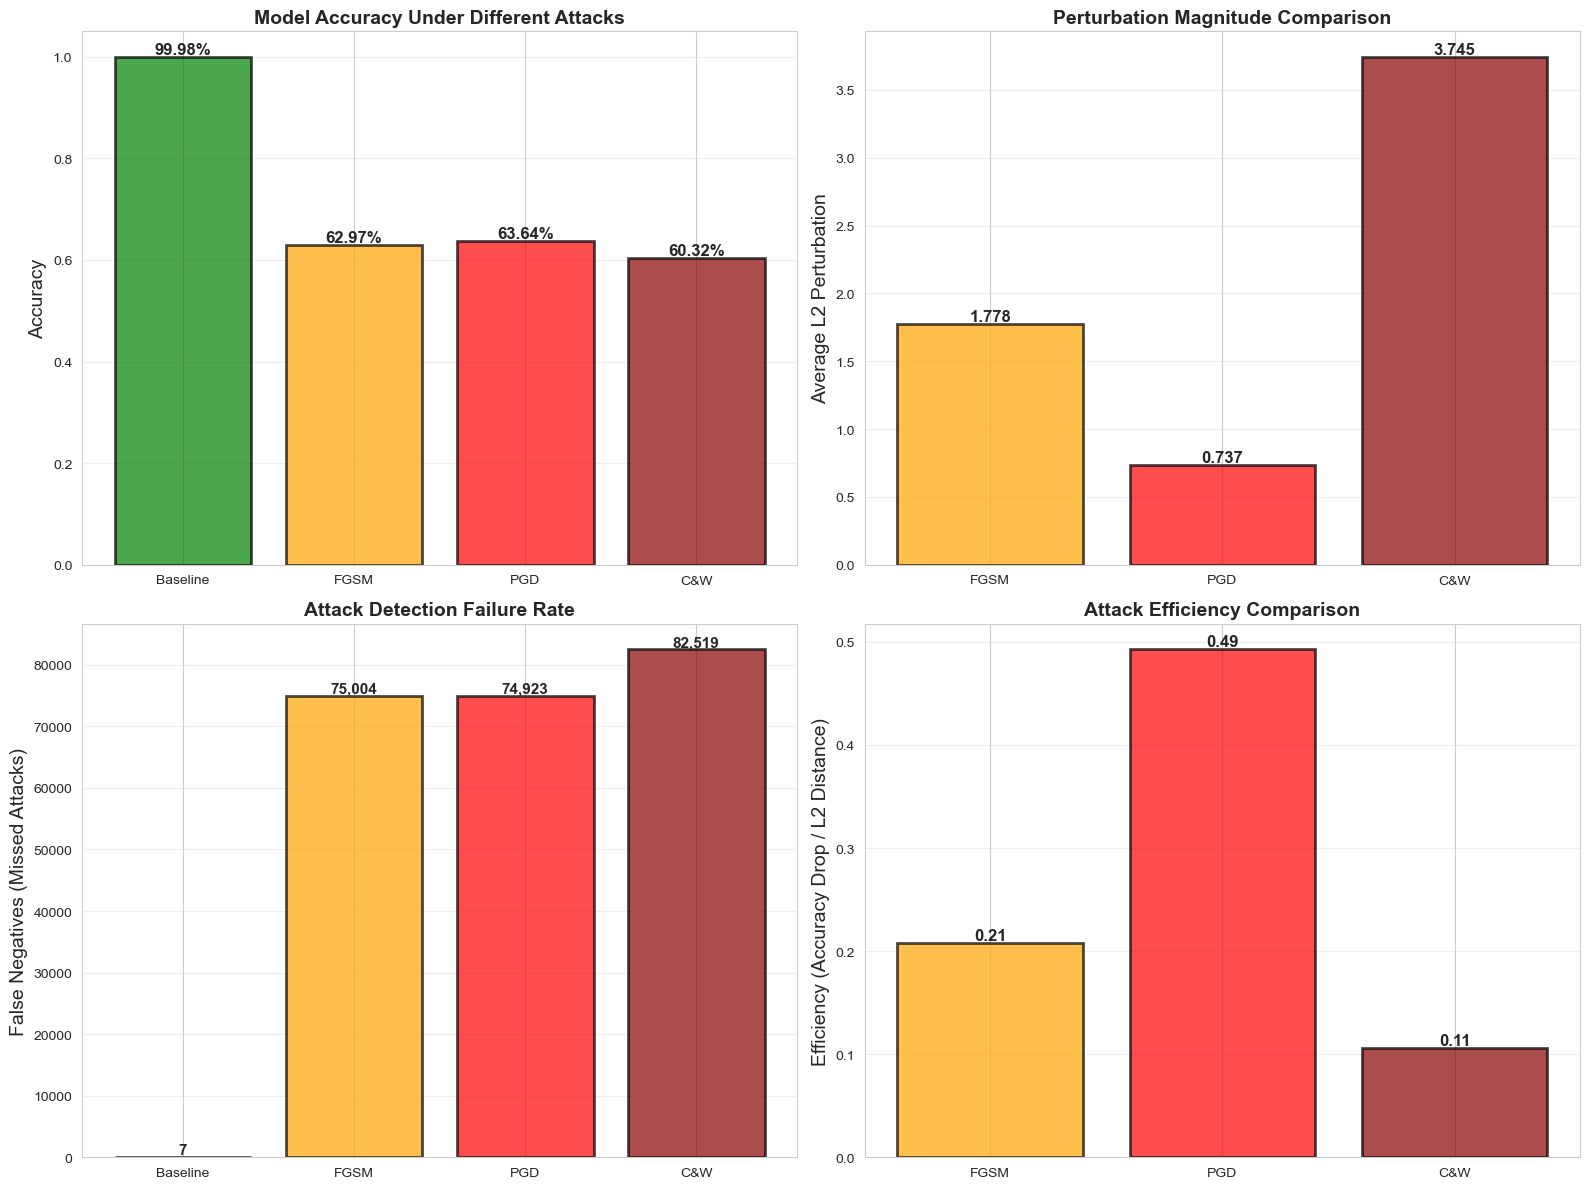

In [11]:
print("\n" + "="*60)
print("VISUALIZING ATTACK EFFECTIVENESS")
print("="*60)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison
ax1 = axes[0, 0]
attacks = ['Baseline', 'FGSM', 'PGD', 'C&W']
accuracies = [
    baseline_accuracy,
    fgsm_results['best_accuracy'],
    pgd_results['best_config']['accuracy'],
    cw_accuracy
]
colors = ['green', 'orange', 'red', 'darkred']

bars = ax1.bar(attacks, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_ylabel('Accuracy', fontsize=14)
ax1.set_title('Model Accuracy Under Different Attacks', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1.05])
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Perturbation size comparison
ax2 = axes[0, 1]
attacks_pert = ['FGSM', 'PGD', 'C&W']
perturbations = [fgsm_l2, pgd_l2, cw_l2]
colors_pert = ['orange', 'red', 'darkred']

bars2 = ax2.bar(attacks_pert, perturbations, color=colors_pert, alpha=0.7, edgecolor='black', linewidth=2)

for bar, pert in zip(bars2, perturbations):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{pert:.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_ylabel('Average L2 Perturbation', fontsize=14)
ax2.set_title('Perturbation Magnitude Comparison', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Confusion matrices for all attacks
cm_original = baseline_metrics['confusion_matrix']
cm_fgsm = confusion_matrix(y_test, baseline_model.predict(X_test_fgsm))
cm_pgd = confusion_matrix(y_test, baseline_model.predict(X_test_pgd))

# Stack confusion matrices for comparison
ax3 = axes[1, 0]
attack_names = ['Baseline', 'FGSM', 'PGD', 'C&W']
fn_counts = [cm_original[1][0], cm_fgsm[1, 0], cm_pgd[1, 0], cm_cw[1, 0]]

bars3 = ax3.bar(attack_names, fn_counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, count in zip(bars3, fn_counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax3.set_ylabel('False Negatives (Missed Attacks)', fontsize=14)
ax3.set_title('Attack Detection Failure Rate', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Efficiency (accuracy drop per unit perturbation)
ax4 = axes[1, 1]
attacks_eff = ['FGSM', 'PGD', 'C&W']
efficiency = [
    (baseline_accuracy - fgsm_results['best_accuracy']) / fgsm_l2,
    pgd_results['best_config']['accuracy_drop'] / pgd_l2,
    cw_drop / cw_l2
]

bars4 = ax4.bar(attacks_eff, efficiency, color=colors_pert, alpha=0.7, edgecolor='black', linewidth=2)

for bar, eff in zip(bars4, efficiency):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{eff:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax4.set_ylabel('Efficiency (Accuracy Drop / L2 Distance)', fontsize=14)
ax4.set_title('Attack Efficiency Comparison', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/cw_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved comprehensive comparison plot")
plt.show()


In [12]:
print("\n" + "="*60)
print("SAVING C&W RESULTS")
print("="*60)

# Save adversarial examples
np.save('../data/adversarial/X_test_cw.npy', X_test_cw_full)
print("✓ Saved C&W adversarial examples")

# Save results
cw_results = {
    'configurations': results_df.to_dict(),
    'best_config': {
        'c': best_config['c'],
        'learning_rate': best_config['learning_rate'],
        'max_iter': int(best_config['max_iter']),
        'accuracy': cw_accuracy,
        'accuracy_drop': cw_drop,
        'avg_l2_distance': avg_l2_full
    },
    'confusion_matrix': cm_cw.tolist(),
    'perturbation_stats': {
        'mean': avg_l2_full,
        'max': max_l2_full,
        'min': min_l2_full
    },
    'comparison': comparison.to_dict()
}

joblib.dump(cw_results, '../models/attacks/cw_results.pkl')
print("✓ Saved C&W results")

# Update attack comparison CSV
comparison.to_csv('../results/benchmarks/attack_comparison_with_cw.csv', index=False)
print("✓ Updated attack comparison table")



SAVING C&W RESULTS
✓ Saved C&W adversarial examples
✓ Saved C&W results
✓ Updated attack comparison table


In [13]:
print("\n" + "="*80)
print(" "*25 + "C&W ATTACK SUMMARY")
print("="*80)

summary = f"""
Baseline Model:
  Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)

Attack Comparison:
  FGSM Accuracy:  {fgsm_results['best_accuracy']:.4f} ({fgsm_results['best_accuracy']*100:.2f}%)
  PGD Accuracy:   {pgd_results['best_config']['accuracy']:.4f} ({pgd_results['best_config']['accuracy']*100:.2f}%)
  C&W Accuracy:   {cw_accuracy:.4f} ({cw_accuracy*100:.2f}%)

C&W Performance:
  Accuracy drop: {cw_drop:.4f} ({cw_drop*100:.2f} percentage points)
  Average L2 perturbation: {avg_l2_full:.4f}
  
Perturbation Efficiency:
  FGSM: {(baseline_accuracy - fgsm_results['best_accuracy']) / fgsm_l2:.2f} accuracy drop per L2 unit
  PGD:  {pgd_results['best_config']['accuracy_drop'] / pgd_l2:.2f} accuracy drop per L2 unit
  C&W:  {cw_drop / cw_l2:.2f} accuracy drop per L2 unit

Key Finding:
  C&W {'achieved the strongest attack' if cw_accuracy < min(fgsm_results['best_accuracy'], pgd_results['best_config']['accuracy']) else 'confirmed the vulnerability floor'}
  {'with smaller perturbations than FGSM/PGD' if cw_l2 < fgsm_l2 else 'using optimization-based approach'}

Files Saved:
  ✓ C&W adversarial examples: data/adversarial/X_test_cw.npy
  ✓ C&W results: models/attacks/cw_results.pkl
  ✓ Updated comparison: results/benchmarks/attack_comparison_with_cw.csv
  ✓ Comprehensive plot: results/figures/cw_comprehensive_comparison.png
"""

print(summary)

print("="*80)
print("✅ C&W ATTACK IMPLEMENTATION COMPLETE!")
print("="*80)
print("\nNext: Cross-Model Transfer Attack (Day 6)")
print("\nYou now have the three strongest attacks in adversarial ML!")
print("FGSM (fast), PGD (iterative), C&W (optimization-based)")



                         C&W ATTACK SUMMARY

Baseline Model:
  Accuracy: 0.9998 (99.98%)

Attack Comparison:
  FGSM Accuracy:  0.6297 (62.97%)
  PGD Accuracy:   0.6364 (63.64%)
  C&W Accuracy:   0.6032 (60.32%)

C&W Performance:
  Accuracy drop: 0.3966 (39.66 percentage points)
  Average L2 perturbation: 3.7448

Perturbation Efficiency:
  FGSM: 0.21 accuracy drop per L2 unit
  PGD:  0.49 accuracy drop per L2 unit
  C&W:  0.11 accuracy drop per L2 unit

Key Finding:
  C&W achieved the strongest attack
  using optimization-based approach

Files Saved:
  ✓ C&W adversarial examples: data/adversarial/X_test_cw.npy
  ✓ C&W results: models/attacks/cw_results.pkl
  ✓ Updated comparison: results/benchmarks/attack_comparison_with_cw.csv
  ✓ Comprehensive plot: results/figures/cw_comprehensive_comparison.png

✅ C&W ATTACK IMPLEMENTATION COMPLETE!

Next: Cross-Model Transfer Attack (Day 6)

You now have the three strongest attacks in adversarial ML!
FGSM (fast), PGD (iterative), C&W (optimization